# Objective

The objective of this experiment is to extract psychoacoustic Bark Scale features from the RAVDESS speech emotion dataset.

Unlike MFCCs, which approximate human auditory perception using the Mel scale, Bark features represent the critical bands of human hearing more directly. These features will later be integrated with pitch, loudness, and spectral features to construct the Unified Psychoacoustic Representation Framework proposed in this research.

# Introduction

Human hearing is nonlinear.

The Bark Scale models the perceptual frequency resolution of the human auditory system by dividing the audible frequency range into approximately 24 critical bands.

Each Bark band corresponds to a frequency region processed similarly by the cochlea.

By extracting energy from these perceptual bands, we obtain psychoacoustic descriptors that are more closely aligned with human emotion perception than conventional spectral features.


Audio Signal

↓

Short-Time Fourier Transform

↓

Power Spectrum

↓

Bark Filter Bank

↓

24 Bark Bands

↓

Average Energy

↓

Feature Vector

Mathematical Background

We will include the Bark conversion equation.

The Bark scale is approximated by:

z=13tan−1(0.00076f)+3.5tan−1(f/7500)2

This converts frequency f (Hz) into Bark units.

Later, we will implement this equation ourselves.

In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)



In [2]:
import librosa
import librosa.display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

from Utils.dataset_loader import get_audio_files
from Utils.constants import SAMPLE_RATE
from Features.bark import hz_to_bark
from Features.bark import create_bark_filterbank
from Features.bark import extract_bark_features

#Waveform

In [3]:
audio_files = get_audio_files()

print("Total Files:", len(audio_files))

Total Files: 2880


In [4]:
sample_file = audio_files[0]

print(sample_file)

F:\PhD\PhD_Project\Dataset\Actor_01\03-01-01-01-01-01-01.wav


## Load Sample Audio


In [5]:
audio, sr = librosa.load(
    sample_file,
    sr=SAMPLE_RATE
)

print("Sample Rate :", sr)

print("Number of Samples :", len(audio))

print("Duration :", round(len(audio)/sr,2),"seconds")

Sample Rate : 22050
Number of Samples : 72838
Duration : 3.3 seconds


## Display Audio Waveform

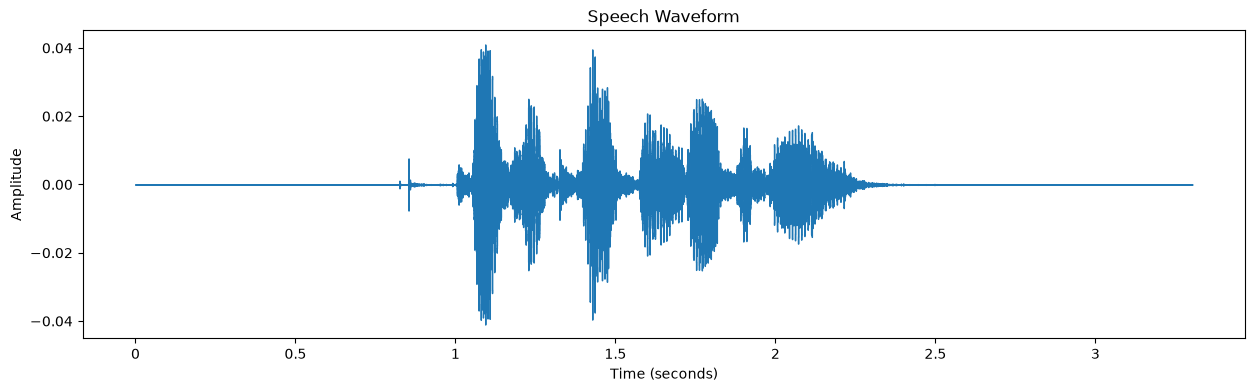

In [6]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Speech Waveform")

plt.xlabel("Time (seconds)")

plt.ylabel("Amplitude")

plt.show()

## Display Spectrogram

Before extracting Bark features, we first visualize the frequency content of the speech signal using a Short-Time Fourier Transform (STFT). The spectrogram shows how speech energy is distributed across time and frequency.

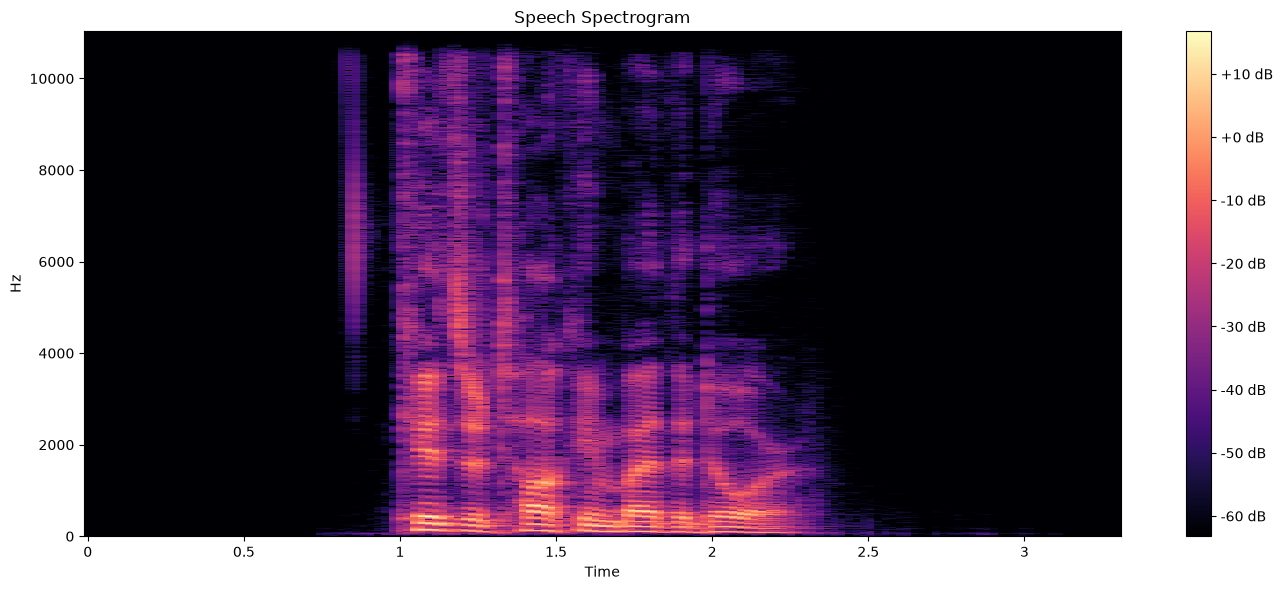

In [7]:
D = np.abs(librosa.stft(audio))

plt.figure(figsize=(14,6))

librosa.display.specshow(
    librosa.amplitude_to_db(D),
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Speech Spectrogram")

plt.tight_layout()

plt.show()

## Observation

The spectrogram represents the distribution of speech energy over time and frequency.

It can be observed that lower frequencies contain stronger energy compared to higher frequencies. However, human hearing does not perceive these frequencies linearly.

To model human auditory perception more accurately, the Bark Scale transforms the linear frequency axis into perceptual critical bands.

The next section implements this Bark Scale transformation.

In [8]:
frequencies = [

    100,
    500,
    1000,
    5000,
    10000

]

for f in frequencies:

    print(

        f,

        "Hz",

        "→",

        round(

            hz_to_bark(f),

            2

        ),

        "Bark"

    )

100 Hz → 0.99 Bark
500 Hz → 4.74 Bark
1000 Hz → 8.51 Bark
5000 Hz → 18.54 Bark
10000 Hz → 22.42 Bark


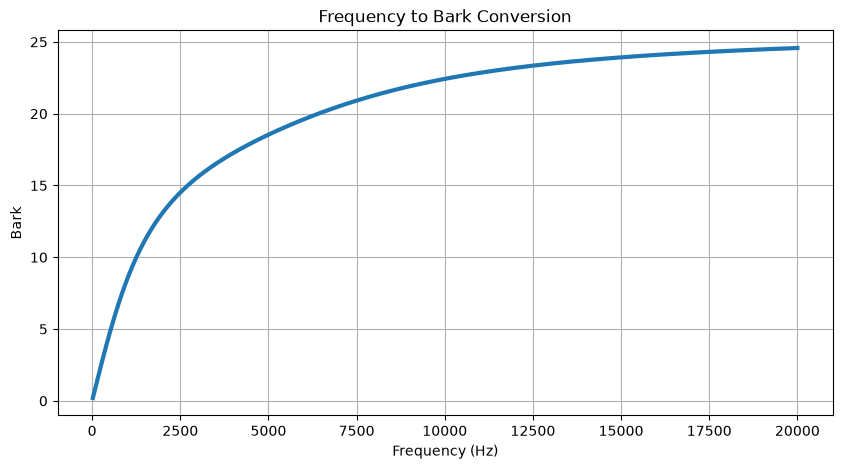

In [9]:
freq = np.linspace(

    20,

    20000,

    1000

)

bark = hz_to_bark(freq)

plt.figure(figsize=(10,5))

plt.plot(

    freq,

    bark,

    linewidth=3

)

plt.xlabel(

    "Frequency (Hz)"

)

plt.ylabel(

    "Bark"

)

plt.title(

    "Frequency to Bark Conversion"

)

plt.grid(True)

plt.show()

### The nonlinear Bark curve demonstrates that human auditory perception allocates higher resolution to low-frequency regions than high-frequency regions. Therefore Bark representations preserve perceptually important emotional cues more effectively than uniformly spaced frequency representations.

In [10]:
print(

    "20 Hz =",

    hz_to_bark(20)

)

print(

    "1000 Hz =",

    hz_to_bark(1000)

)

print(

    "20000 Hz =",

    hz_to_bark(20000)

)

20 Hz = 0.19760967316343087
1000 Hz = 8.510531510721993
20000 Hz = 24.575125911921678


## Short-Time Fourier Transform (STFT)

The STFT converts the speech waveform into the frequency domain. Each column represents one time frame, and each row represents a frequency bin. Bark filters will later group these frequency bins into perceptual critical bands.

In [11]:
D = np.abs(librosa.stft(audio))

print("STFT Shape :", D.shape)

STFT Shape : (1025, 143)


The STFT contains 1025 frequency bins because the default FFT size in Librosa is 2048.

Number of frequency bins:

(2048 / 2) + 1 = 1025

These bins are linearly spaced in frequency.

However, human hearing is nonlinear.

Therefore, these bins will now be grouped into 24 Bark bands.

In [12]:
frequencies = librosa.fft_frequencies(
    sr=sr,
    n_fft=2048
)

print(frequencies.shape)

(1025,)


In [13]:
print(frequencies[:20])


[  0.          10.76660156  21.53320312  32.29980469  43.06640625
  53.83300781  64.59960938  75.36621094  86.1328125   96.89941406
 107.66601562 118.43261719 129.19921875 139.96582031 150.73242188
 161.49902344 172.265625   183.03222656 193.79882812 204.56542969]


In [14]:
bark_values = hz_to_bark(frequencies)

print(bark_values[:20])

[0.         0.10637886 0.21275791 0.31912291 0.42545965 0.53175397
 0.63799174 0.74415887 0.85024138 0.95622534 1.06209691 1.16784235
 1.27344805 1.3789005  1.48418633 1.5892923  1.69420534 1.79891252
 1.90340109 2.00765847]


In [15]:
filterbank, bark, bark_points = create_bark_filterbank()

print("Filterbank Shape :", filterbank.shape)

print("Bark Points :", bark_points)

Filterbank Shape : (24, 1025)
Bark Points : [ 0.          0.91427864  1.82855729  2.74283593  3.65711458  4.57139322
  5.48567187  6.39995051  7.31422916  8.2285078   9.14278645 10.05706509
 10.97134374 11.88562238 12.79990103 13.71417967 14.62845832 15.54273696
 16.4570156  17.37129425 18.28557289 19.19985154 20.11413018 21.02840883
 21.94268747 22.85696612]


## Bark Band Boundaries

The Bark Scale ranges from approximately 0 to 24 Bark.

The filter bank divides this range into 24 perceptual critical bands.

Each band will later accumulate the energy of the FFT bins falling within its Bark interval.

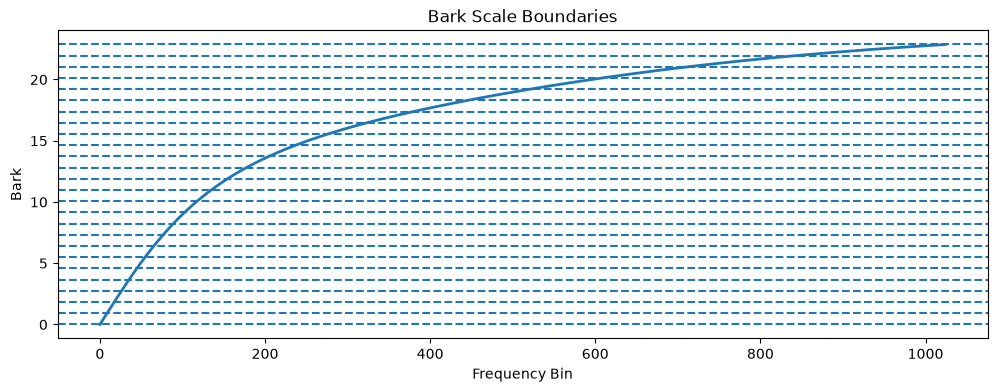

In [16]:
plt.figure(figsize=(12,4))

plt.plot(
    bark,
    linewidth=2
)

for point in bark_points:

    plt.axhline(
        point,
        linestyle="--"
    )

plt.xlabel("Frequency Bin")

plt.ylabel("Bark")

plt.title("Bark Scale Boundaries")

plt.show()

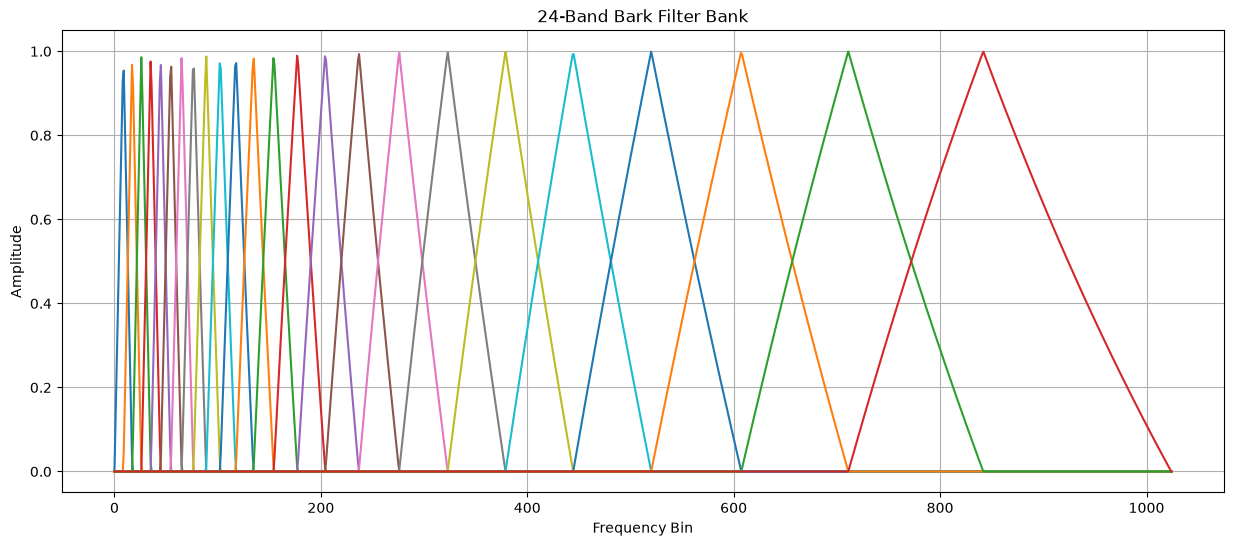

In [17]:
plt.figure(figsize=(15,6))

for i in range(filterbank.shape[0]):
    plt.plot(filterbank[i])

plt.title("24-Band Bark Filter Bank")

plt.xlabel("Frequency Bin")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [18]:
sample = audio_files[0]

features = extract_bark_features(sample)

print(features.shape)

print(features)

(24,)
[1.22456802 1.58191184 1.69468604 1.92794133 2.42038903 1.44067441
 0.64873988 0.05549319 0.08543606 0.28481231 0.21493634 0.15054544
 0.14352907 0.11564024 0.08096528 0.12689895 0.07291389 0.12517562
 0.02495175 0.03905695 0.0227837  0.00735823 0.00490713 0.00498636]


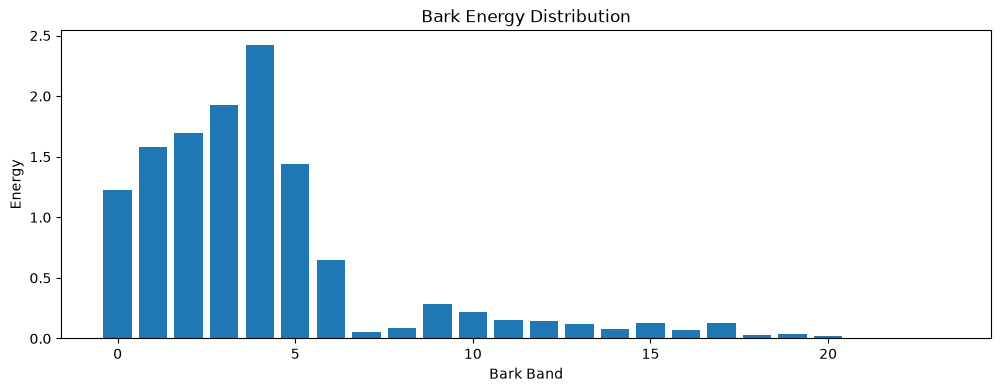

In [19]:
plt.figure(figsize=(12,4))

plt.bar(
    range(24),
    features
)

plt.xlabel("Bark Band")

plt.ylabel("Energy")

plt.title("Bark Energy Distribution")

plt.show()

### Bark Energy Representation

Each speech signal is transformed into a 24-dimensional psychoacoustic representation.

Each dimension corresponds to the average energy contained within one Bark critical band.

These Bark energies approximate the nonlinear frequency resolution of the human auditory system and provide perceptually meaningful descriptors for emotion recognition.

In [20]:
results = []
emotion_map = {
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fearful",
    "07":"disgust",
    "08":"surprised"
}

In [21]:
from tqdm import tqdm

for file in tqdm(audio_files):

    feature = extract_bark_features(file)

    emotion = emotion_map[
        os.path.basename(file).split("-")[2]
    ]

    row = {
        "file":os.path.basename(file),
        "emotion":emotion
    }

    for i in range(24):
        row[f"bark_{i+1}"] = feature[i]

    results.append(row)

100%|██████████| 2880/2880 [06:57<00:00,  6.90it/s]


In [22]:
bark_df = pd.DataFrame(results)

bark_df.head()


,file,emotion,bark_1,bark_2,bark_3,bark_4,bark_5,bark_6,bark_7,bark_8,...,bark_15,bark_16,bark_17,bark_18,bark_19,bark_20,bark_21,bark_22,bark_23,bark_24
0,03-01-01-01-01-01-01.wav,neutral,1.224568,1.581912,1.694686,1.927941,2.420389,1.440674,0.648740,0.055493,...,0.080965,0.126899,0.072914,0.125176,0.024952,0.039057,0.022784,0.007358,0.004907,0.004986
1,03-01-01-01-01-02-01.wav,neutral,1.579286,2.003364,2.417665,2.154689,2.361340,1.373473,0.917716,0.051427,...,0.050963,0.105497,0.058767,0.126245,0.036170,0.032045,0.022836,0.010332,0.006254,0.009445
2,03-01-01-01-02-01-01.wav,neutral,1.527839,2.025811,2.770633,2.400824,3.047444,3.466374,1.890323,0.154838,...,0.071865,0.101397,0.063902,0.172677,0.118695,0.296468,0.103690,0.050016,0.016526,0.023940
3,03-01-01-01-02-02-01.wav,neutral,1.941020,1.818957,1.641379,2.508856,2.650654,2.855095,2.286301,0.305160,...,0.055856,0.178260,0.054510,0.159850,0.140705,0.209543,0.102582,0.034135,0.025814,0.041415
4,03-01-02-01-01-01-01.wav,calm,0.874182,1.252065,1.359980,0.870320,1.052927,0.503778,0.253887,0.038347,...,0.036739,0.058829,0.012897,0.027458,0.012568,0.021912,0.033628,0.013598,0.006352,0.006867


In [23]:
output_path = r"F:\PhD\PhD_Project\Outputs\bark_features.csv"

bark_df.to_csv(
    output_path,
    index=False
)

print("Saved Successfully")

Saved Successfully


In [24]:
print(bark_df.shape)

(2880, 26)
